# Brain Tumor Detection using Deep Learning

### Complete AI Pipeline for Medical Image Analysis




This notebook implements a complete pipeline for detecting brain tumors in MRI images using:

1.  **Data Cleaning and Preprocessing:** This initial phase involves gathering the MRI brain scan dataset and performing essential preprocessing steps such as data cleaning, normalization, and preparing the images for optimal model training.
2.  **Exploratory Data Analysis:** We will conduct a thorough exploratory analysis of the dataset, visualizing image samples and analyzing the distribution of tumourous and non-tumourous cases.
3.  **Image Processing with OpenCV:** Utilizing the OpenCV library, we will apply various image processing techniques including grayscaling, filtering, thresholding, and blurring. A key step here will be visually isolating potential brain tumours using contour detection.
4.  **Model Training and Evaluation:** This core stage involves training a CNN model for the classification task. We will rigorously evaluate the model's performance using metrics such as confusion matrices and by plotting training/validation accuracy curves and ROC curves.
5.  **Analysis and Interpretation:** Finally, we will analyze and interpret the model's predictions by visualizing the results on sample images to understand how the model performs on unseen data.

<a id="setup"></a>
## 1. Setup and Imports
This section initializes the required libraries and sets up the environment
for data processing, model training, and evaluation.

In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Core libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import random
from tqdm import tqdm
import time

# Image processing
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.transforms import functional as F

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline


Using device: cpu


In [3]:
DATA_DIR = "Brain-Tumor-Detection-Dataset"  
YES_DIR = os.path.join(DATA_DIR, "yes")
NO_DIR  = os.path.join(DATA_DIR, "no")
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 30

print("yes images:", len(os.listdir(YES_DIR)))
print("no images:", len(os.listdir(NO_DIR)))


yes images: 1500
no images: 1500


<a id="preprocessing"></a>
## 2. Data Cleaning & Preprocessing

The dataset is organized into two main folders: 'yes' and 'no'.
- The 'yes' folder contains images of brain MRI scans where a tumor is present.
- The 'no' folder contains images of brain MRI scans where no tumor is present.
Each of these folders contains 1500 images. The images in the 'yes' folder are classified as 'tumours', and the images in the 'no' folder are classified as 'non-tumours'. This dataset is suitable for training a binary classification model to distinguish between brain MRI scans with and without tumors.

Images are standardized in orientation, resized to a fixed resolution, converted
to grayscale, and normalized.


Description of each step involved in the data cleaning and processing stage.

1.  **`Filter image`**: Performs checks to determine if an image file is a valid image. If cv2 can read the image and it has valid dimensions it is conisidered as valid image.

2.  **`Rotate Image`**: This function is responsible for rotating the input image. Check if the image width is greater than the image height then rotation is applied.

3.  **`Resize Image`**: This function scales the image to a specific target size (`SIZE` (256, 256)). This is a crucial preprocessing step to ensure all input images have the same dimensions.

4.  **`Convert to grayscale`**: This function converts a color image into a grayscale image. It can reduce the complexity of the input data and the number of parameters in the model, potentially improving training speed and reducing overfitting, especially here color information is not critical for the task.

5.  **`Normalize image`**: This function performs image normalization. This involves scaling the pixel values of the image to a standard range (0-1).


### 2.1 Check for Valid Images

In [4]:
def is_image_valid(img_path):
    try:
        img = Image.open(img_path)
        img.verify()  # Verify that it is an image or not
        return True
    except (IOError, SyntaxError) as e:
        return False    



In [5]:
#check for corrupted images in YES_DIR
bad_images = []
for img_name in os.listdir(YES_DIR):
    img_path = os.path.join(YES_DIR, img_name)
    if not is_image_valid(img_path):
        bad_images.append(img_name)
print("Invalid images in YES_DIR:", len(bad_images))


Invalid images in YES_DIR: 0


In [6]:
#check for corrupted images in NO_DIR
bad_images = []

for img_name in os.listdir(NO_DIR):
    img_path = os.path.join(NO_DIR, img_name)
    if not is_image_valid(img_path):
        bad_images.append(img_name)
print("Invalid images in NO_DIR:", bad_images)

Invalid images in NO_DIR: []


### 2.2 Standardize Orientation


In [7]:
def standardize_orientation(image):

    h, w = image.shape[:2]
    if w > h:
        # "Rotate 90° CW if width > height, else return original.
        image = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    return image


### 2.3 Resize and Normalize Images


In [8]:
def resize_image(image, target_size=IMG_SIZE):
    """Resize image to target size using area interpolation."""
    return cv2.resize(image, target_size, interpolation=cv2.INTER_AREA)

def normalize_image(image):
    """Normalize pixel values to [0, 1] range."""
    if image.dtype != np.float32:
        image = image.astype(np.float32)
    return image / 255.0


### 2.4 Convert to Grayscale

In [9]:
def to_grayscale(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [10]:
img_path = os.path.join(YES_DIR, os.listdir(YES_DIR)[0])

In [11]:
original = cv2.imread(img_path)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)


In [14]:
#preprocess the image step by step on one image in order to visualize the changes
standardized = standardize_orientation(original)
resized = resize_image(standardized)
gray = to_grayscale(resized)
normalized = normalize_image(gray)


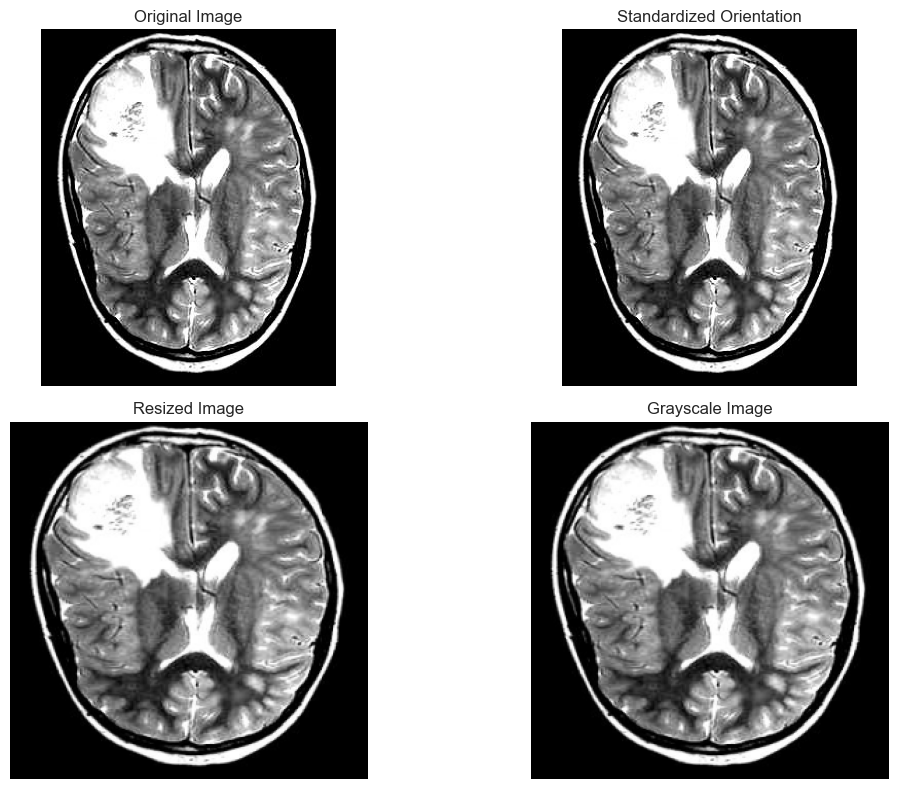

In [15]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.title("Original Image")
plt.imshow(original_rgb)
plt.axis("off")
plt.grid(False)

plt.subplot(2, 2, 2)
plt.title("Standardized Orientation")
plt.imshow(cv2.cvtColor(standardized, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.grid(False)

plt.subplot(2, 2, 3)
plt.title("Resized Image")
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.grid(False)

plt.subplot(2, 2, 4)
plt.title("Grayscale Image")
plt.imshow(gray, cmap="gray")
plt.axis("off")
plt.grid(False)

plt.tight_layout()
plt.show()


<a id="eda"></a>
## 3. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the dataset characteristics.
This includes visualizing sample images from each class,class distribution and analyzing variations of image size.

The dataset is balanced with an equal number of tumor and non-tumor images which helps preventing bias during training.


### 3.1 Class Distribution


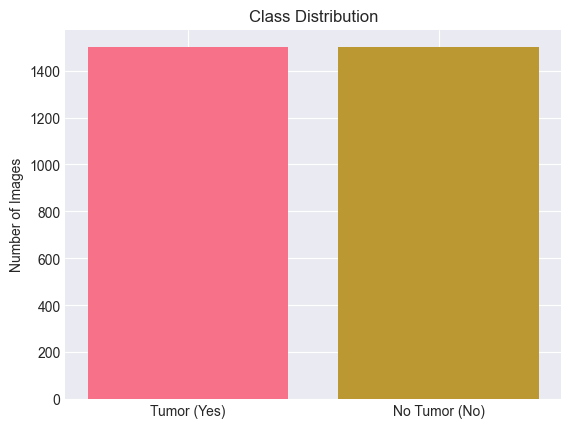

Tumor images: 1500
No tumor images: 1500


In [129]:
import os
import matplotlib.pyplot as plt

yes_count = len(os.listdir(YES_DIR))
no_count  = len(os.listdir(NO_DIR))

plt.bar(["Tumor (Yes)", "No Tumor (No)"], [yes_count, no_count],color=['C0','C1'])
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

print("Tumor images:", yes_count)
print("No tumor images:", no_count)


This plot shows the distribution of tumor and non-tumor images.
The dataset is balanced with an equal number of tumor and non-tumor images.
This makes sure fair training and avoids bias toward any class.

### 3.2 Visualize Sample Images


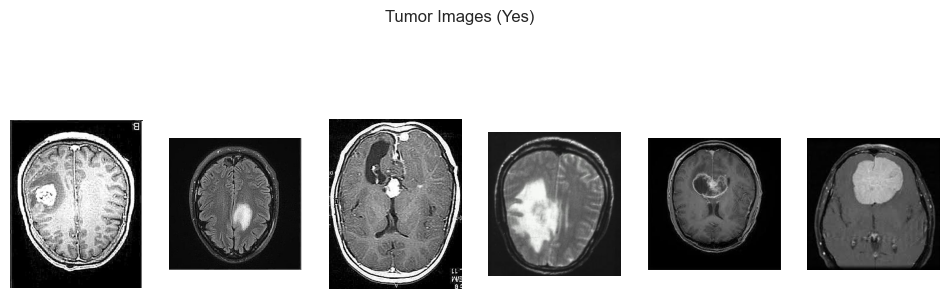

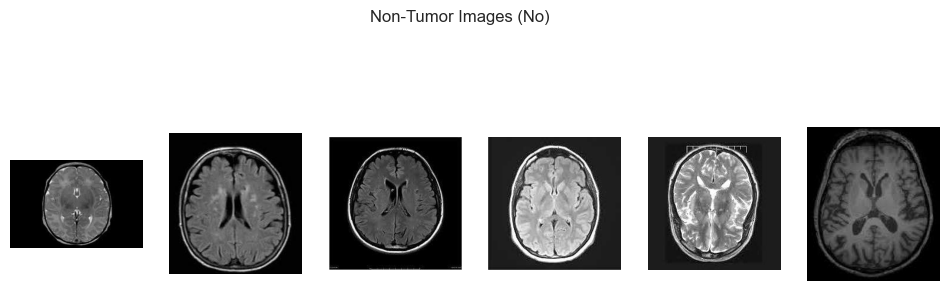

In [17]:
import random
from PIL import Image

#show random samples from each class
def show_samples(folder, title, n=6):
    files = random.sample(os.listdir(folder), n)
    plt.figure(figsize=(12, 4))

    for i, f in enumerate(files):
        img = Image.open(os.path.join(folder, f))
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap="gray")
        plt.axis("off")

    plt.suptitle(title)
    plt.show()

show_samples(YES_DIR, "Tumor Images (Yes)")
show_samples(NO_DIR, "Non-Tumor Images (No)")

Here we shows few sample MRI images from both the classes. The tumor images show abnormal bright regions and the non-tumor images look normal. 

In [132]:
import cv2

sizes = []

for folder in [YES_DIR, NO_DIR]:
    for f in os.listdir(folder):
        img = cv2.imread(os.path.join(folder, f))
        if img is not None:
            sizes.append(img.shape[:2])  # (height, width)

heights = [s[0] for s in sizes]
widths  = [s[1] for s in sizes]

print("Min height:", min(heights), "Max height:", max(heights))
print("Min width :", min(widths),  "Max width :", max(widths))


Min height: 167 Max height: 1427
Min width : 150 Max width : 1920


Before image preprocessing we checked the dimensions of the images. The dataset contained MRI images with different sizes and we need to resize all images for CNN training as CNN requires fixed input size.

### 4. Image Processing with OpenCV
Classical image processing techniques are applied to better understand MRI images.
Grayscale conversion, Gaussian blur, thresholding, and contour detection are used
to highlight abnormal regions.

### 4.1 Filtering Operations (Blur, Threshold)


In [133]:
def detect_tumor_contours(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(
        blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    return contours, thresh


### 4.2 Tumor Contour Detection (Region Isolation)


In [134]:
def visualize_contour_detection(image_path, label):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load image: {image_path}")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    contours, thresh = detect_tumor_contours(image)

    print("Contours detected:", len(contours))  # DEBUG LINE

    image_with_contours = image_rgb.copy()
    cv2.drawContours(image_with_contours, contours, -1, (255, 0, 0), 2)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(image_rgb)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(thresh, cmap="gray")
    plt.title("Thresholded")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(image_with_contours)
    plt.title(f"Contours ({len(contours)})")
    plt.axis("off")

    plt.show()


Contours detected: 1


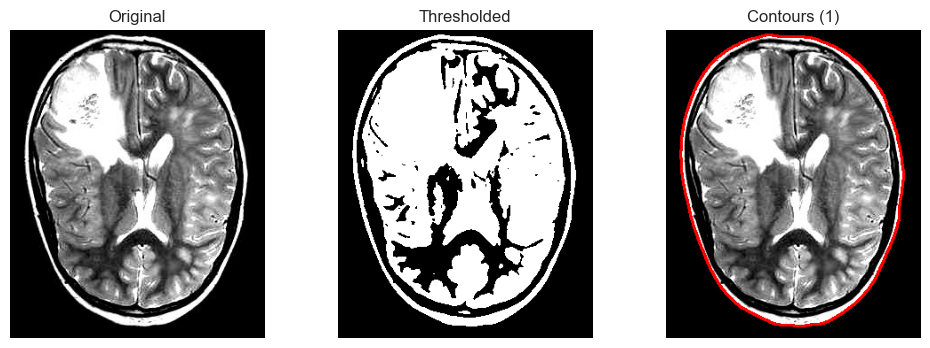

In [135]:
yes_sample = os.path.join(DATA_DIR, "yes", "y0.jpg")
visualize_contour_detection(yes_sample, "Tumor")


Contours detected: 1


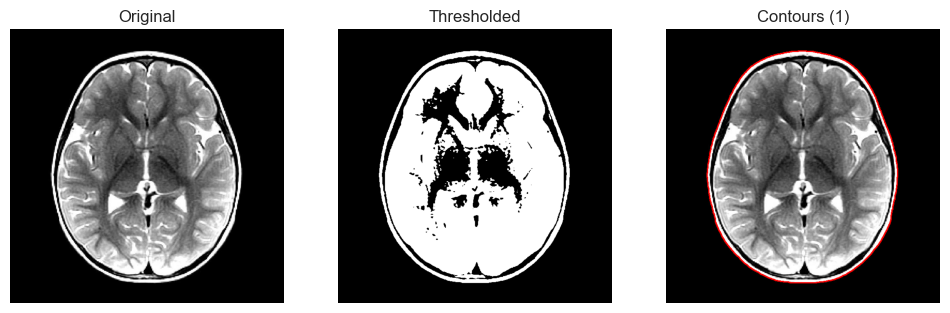

In [136]:
no_sample = os.path.join(DATA_DIR, "no", "no0.jpg")
visualize_contour_detection(no_sample, "No-Tumor")